# Notebook 01 — Exploratory Data Analysis

## Setup and Configuration

This section prepares the environment for exploratory data analysis by importing all required libraries and loading project-specific configuration parameters. The imported libraries cover data manipulation (pandas, numpy), visualisation (matplotlib, seaborn), and text processing (CountVectorizer, WordCloud), which are essential for analysing textual datasets.

The configuration file provides centralised access to key constants such as dataset paths, maximum sequence length, vocabulary constraints, and predefined linguistic cues (e.g., negations and intensifiers). This ensures consistency across different stages of the pipeline and improves maintainability.

In addition, global plotting settings are defined to ensure uniform visualisation aesthetics throughout the notebook. A class-specific colour palette is also specified for consistent representation of labels. Finally, the required directory structure for storing EDA outputs is created to maintain an organised workflow.

In [1]:
# System path setup 
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Core libraries
import pandas as pd
import numpy as np

# Visualisation libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Text processing and analysis
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

import re

# Project configuration 
from config import (
    RAW_CSV, PLOTS_DIR, MAX_LENGTH,
    WORDCLOUD_MAX, TOP_N_NGRAMS, 
    NEGATION_CUES, INTENSIFIERS,
)

# Global plotting style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Class-wise colour palette
PALETTE = {
    'suicide': '#E63946',
    'non-suicide': '#457B9D'
}

# Create directory for EDA outputs
os.makedirs(PLOTS_DIR / 'eda', exist_ok=True)

## Data Loading and Initial Cleaning

In this step, the dataset is loaded from the configured file path and undergoes initial preprocessing to ensure consistency and data quality. Column names are standardised to remove any unwanted whitespace, and the target column is renamed to a uniform label (`label`) for clarity and compatibility across the pipeline.

Rows with missing values in critical fields such as text or labels are removed to avoid issues during downstream processing and modelling. The index is then reset to maintain a clean and continuous ordering after filtering.

Finally, basic inspection is performed to verify the dataset structure, including its shape and column names, along with a preview of the data.

In [2]:
# Load dataset
df = pd.read_csv(RAW_CSV, index_col=0)

# Standardise column names
df.columns = df.columns.str.strip()

# Rename target column for consistency
df.rename(columns={'class': 'label'}, inplace=True)

# Remove rows with missing text or labels
df.dropna(subset=['text', 'label'], inplace=True)

# Reset index after filtering
df.reset_index(drop=True, inplace=True)

# Basic dataset inspection
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')

df.head()

Dataset shape: (232074, 2)
Columns: ['text', 'label']


,text,label
0,Ex Wife Threatening SuicideRecently I left my ...,suicide
1,Am I weird I don't get affected by compliments...,non-suicide
2,Finally 2020 is almost over... So I can never ...,non-suicide
3,i need helpjust help me im crying so hard,suicide
4,"I’m so lostHello, my name is Adam (16) and I’v...",suicide


## Class Distribution Analysis

This step examines the distribution of target labels within the dataset by computing both absolute counts and percentage proportions. Understanding class balance is essential before modelling, as significant imbalance may bias learning algorithms and require corrective strategies such as resampling or class weighting.

The computed statistics provide a quick overview of how instances are distributed across classes, helping assess whether the dataset is balanced or skewed.

In [3]:
# Compute class distribution (counts and percentages)
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

# Display results
print(class_counts.to_string())
print()
print(class_pct.round(2).to_string())

label
suicide        116037
non-suicide    116037

label
suicide        50.0
non-suicide    50.0


## Class Distribution Visualisation

This section visualises the distribution of target labels using both absolute counts and percentage proportions. A bar chart is used to display the number of instances in each class, while a pie chart illustrates their relative proportions.

Such visualisation provides a clearer understanding of class balance and complements the numerical summary computed earlier. It also helps identify whether any corrective measures, such as class weighting or resampling, may be required during model training.

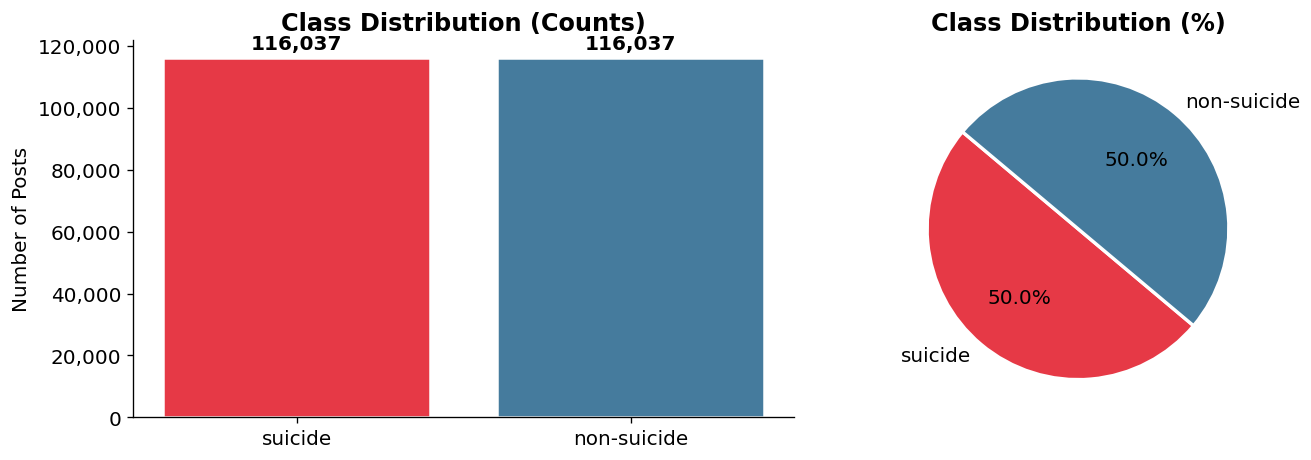

Observation: Dataset is roughly balanced — minimal class weighting needed.


In [4]:
# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart for class counts
bars = axes[0].bar(
    class_counts.index,
    class_counts.values,
    color=[PALETTE[c] for c in class_counts.index],
    edgecolor='white',
    linewidth=1.5
)

# Annotate bar values
for bar, val in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1500,
        f'{val:,}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

axes[0].set_title('Class Distribution (Counts)', fontweight='bold')
axes[0].set_ylabel('Number of Posts')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

# Pie chart for percentage distribution
axes[1].pie(
    class_counts.values,
    labels=class_counts.index,
    colors=[PALETTE[c] for c in class_counts.index],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

axes[1].set_title('Class Distribution (%)', fontweight='bold')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'class_distribution.png', bbox_inches='tight')
plt.show()

print('Observation: Dataset is roughly balanced — minimal class weighting needed.')

## Text Feature Engineering and Summary Statistics

In this step, basic textual features are derived from the raw text to capture structural properties of each post. These include character length, word count, and sentence count, which provide insights into the complexity and verbosity of the text.

Such features are useful for exploratory analysis and may also serve as auxiliary inputs for downstream models. Descriptive statistics are then computed for each feature, grouped by class, to analyse differences in writing patterns across categories.

In [5]:
# Compute text-based features
df['char_len'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['sent_count'] = df['text'].str.count(r'[.!?]') + 1

# Generate descriptive statistics grouped by label
summary = df.groupby('label')[['char_len', 'word_count', 'sent_count']].describe().round(1)
print(summary)

             char_len                                                      \
                count    mean     std  min    25%    50%     75%      max   
label                                                                       
non-suicide  116037.0   329.2   806.4  8.0   99.0  165.0   320.0  40106.0   
suicide      116037.0  1050.1  1328.2  3.0  310.0  653.0  1294.0  40297.0   

            word_count         ...                sent_count                   \
                 count   mean  ...    75%     max      count  mean   std  min   
label                          ...                                              
non-suicide   116037.0   61.2  ...   60.0  8220.0   116037.0   5.5  60.8  1.0   
suicide       116037.0  202.7  ...  251.0  9684.0   116037.0  15.8  21.1  1.0   

                                       
             25%   50%   75%      max  
label                                  
non-suicide  1.0   3.0   5.0  10673.0  
suicide      5.0  10.0  19.0   1938.0  

[2 rows

## Text Length Distribution Analysis

This section visualises the distribution of key text-based features across classes using kernel density estimation (KDE). The features include word count, character length, and sentence count, which capture different aspects of text structure and complexity.

To reduce the influence of extreme outliers and improve visual clarity, values are clipped at the 99th percentile before plotting. This allows for a more meaningful comparison of typical patterns between classes.

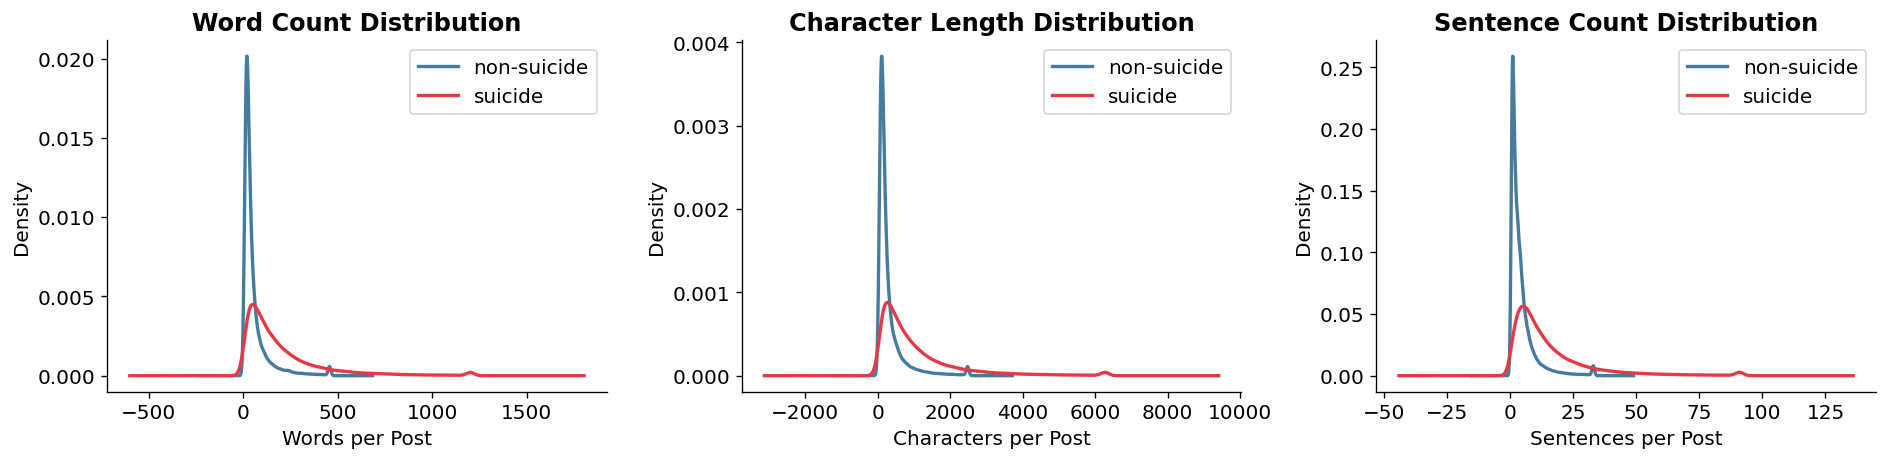

In [6]:
# Create subplots for feature distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot KDE distributions for each feature
for ax, col, title, xlabel in zip(
    axes,
    ['word_count', 'char_len', 'sent_count'],
    ['Word Count Distribution', 'Character Length Distribution', 'Sentence Count Distribution'],
    ['Words per Post', 'Characters per Post', 'Sentences per Post']
):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.kde(
            ax=ax,
            label=label,
            color=PALETTE[label],
            linewidth=2
        )
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'text_length_distribution.png', bbox_inches='tight')
plt.show()

## Word Count Distribution by Class

This section presents a box plot to compare the distribution of word counts across different classes. Box plots provide a compact summary of the data by highlighting the median, interquartile range, and potential outliers.

This visualisation helps identify differences in text length patterns between classes and assess variability within each group.

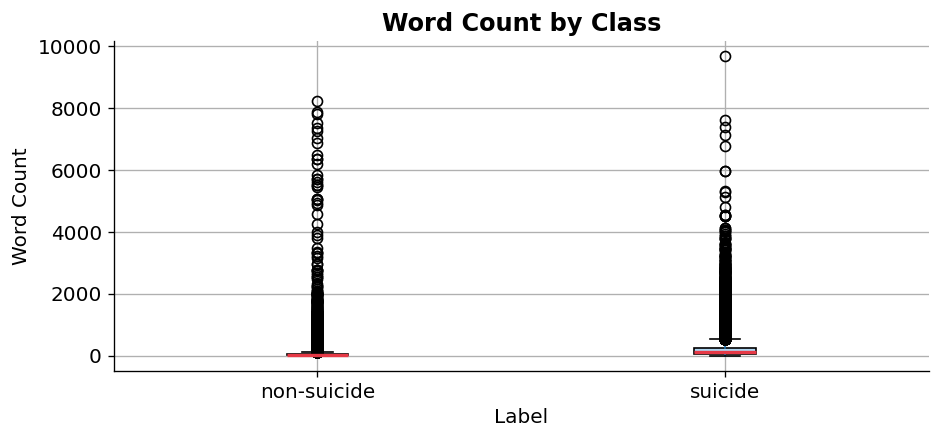

In [7]:
# Box plot for word count grouped by label
fig, ax = plt.subplots(figsize=(8, 4))

df.boxplot(
    column='word_count',
    by='label',
    ax=ax,
    patch_artist=True,
    boxprops=dict(facecolor='#AED6F1'),
    medianprops=dict(color='#E63946', linewidth=2)
)

ax.set_title('Word Count by Class', fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Word Count')

# Remove default pandas title
plt.suptitle('')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'wordcount_boxplot.png', bbox_inches='tight')
plt.show()

## Sequence Length and Truncation Analysis

This section estimates the proportion of posts that exceed the maximum input sequence length defined by the model. Since exact tokenisation is model-dependent, word count is used as a conservative proxy for token count.

Understanding truncation behaviour is important, as excessive truncation may lead to loss of critical contextual information. A histogram of word counts is also plotted, with the truncation threshold highlighted, to visualise how much of the dataset is affected.

Approximate % of posts that will be truncated at MAX_LENGTH=128: 29.7%


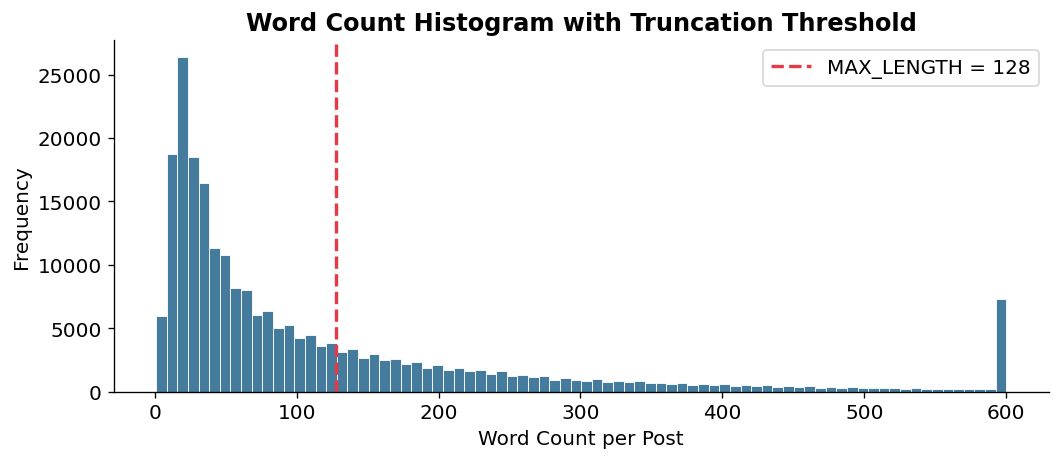

In [8]:
# Estimate truncation percentage using word count as proxy for tokens
pct_truncated = (df['word_count'] > MAX_LENGTH).mean() * 100

print(f'Approximate % of posts that will be truncated at MAX_LENGTH={MAX_LENGTH}: {pct_truncated:.1f}%')

# Plot histogram of word counts with truncation threshold
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(
    df['word_count'].clip(upper=600),
    bins=80,
    color='#457B9D',
    edgecolor='white',
    linewidth=0.5
)

# Mark truncation threshold
ax.axvline(
    MAX_LENGTH,
    color='#E63946',
    linewidth=2,
    linestyle='--',
    label=f'MAX_LENGTH = {MAX_LENGTH}'
)

ax.set_xlabel('Word Count per Post')
ax.set_ylabel('Frequency')
ax.set_title('Word Count Histogram with Truncation Threshold', fontweight='bold')
ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'truncation_threshold.png', bbox_inches='tight')
plt.show()

## Word Cloud Analysis

This section generates word clouds for each class to visualise the most frequently occurring terms in the text data. A minimal cleaning function is applied to remove URLs and punctuation while preserving the core lexical content.

Word clouds provide an intuitive way to identify dominant themes and commonly used words within each class, offering qualitative insights into differences in language usage.

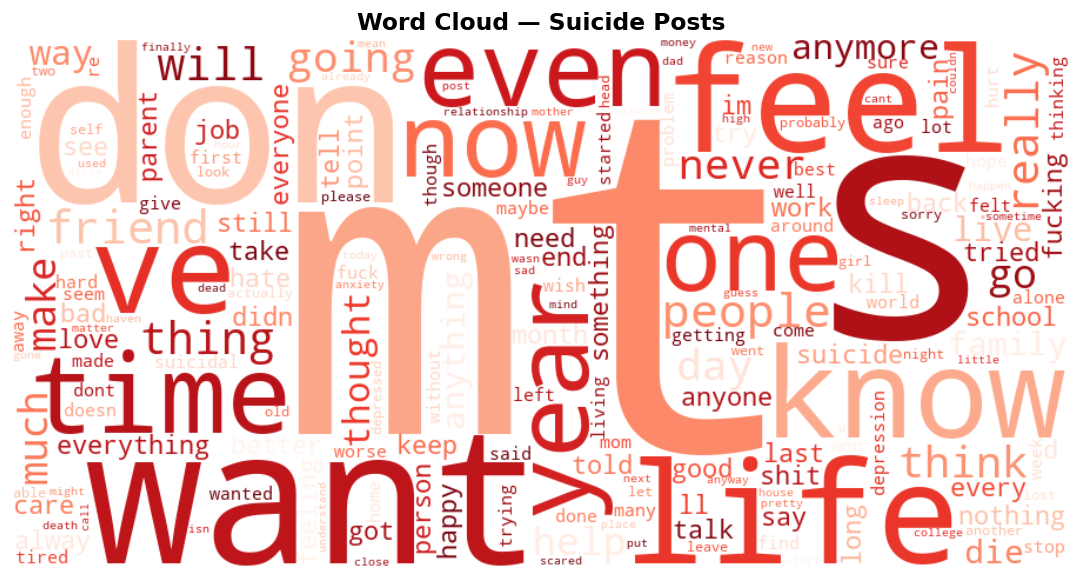

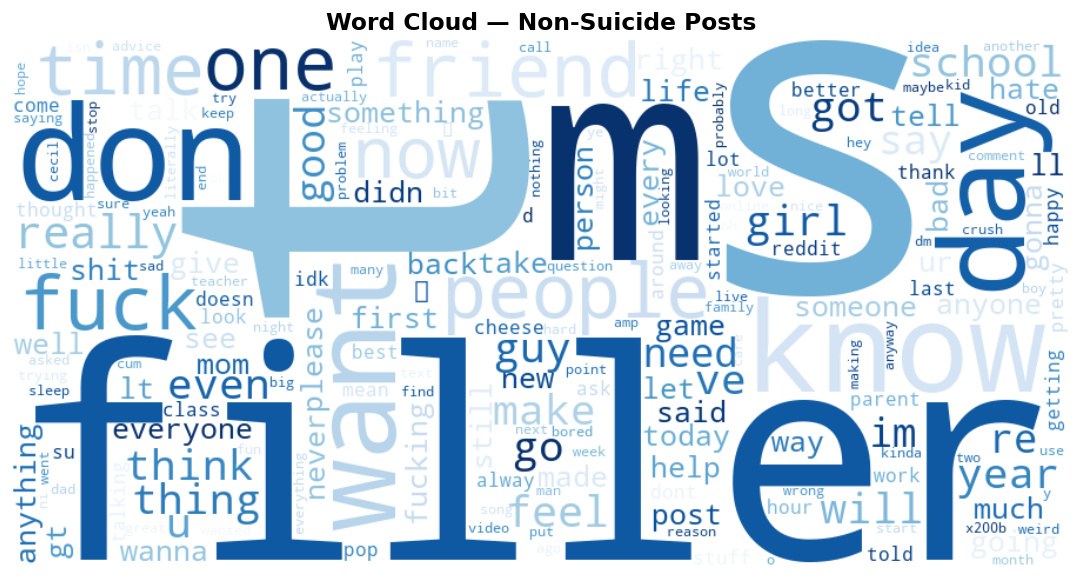

In [9]:
# Minimal text cleaning for word cloud generation
def simple_clean(text):
    text = re.sub(r'http\S+', '', str(text))
    text = re.sub(r'[^\w\s]', ' ', text)
    return text.lower()

# Generate word clouds for each class
for label in ['suicide', 'non-suicide']:
    corpus = ' '.join(df[df['label'] == label]['text'].apply(simple_clean))

    wc = WordCloud(
        width=900,
        height=450,
        background_color='white',
        colormap='Reds' if label == 'suicide' else 'Blues',
        max_words=WORDCLOUD_MAX,
        collocations=False
    ).generate(corpus)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {label.title()} Posts', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.savefig(
        PLOTS_DIR / 'eda' / f'wordcloud_{label.replace("-", "_")}.png',
        bbox_inches='tight'
    )
    plt.show()

## N-gram Frequency Analysis

This section analyses the most frequent unigrams and bigrams for each class using a bag-of-words representation. N-grams capture commonly occurring words and word combinations, providing deeper insight into language patterns beyond individual terms.

By comparing n-gram frequencies across classes, it becomes possible to identify distinguishing phrases and contextual patterns that may be useful for downstream modelling.


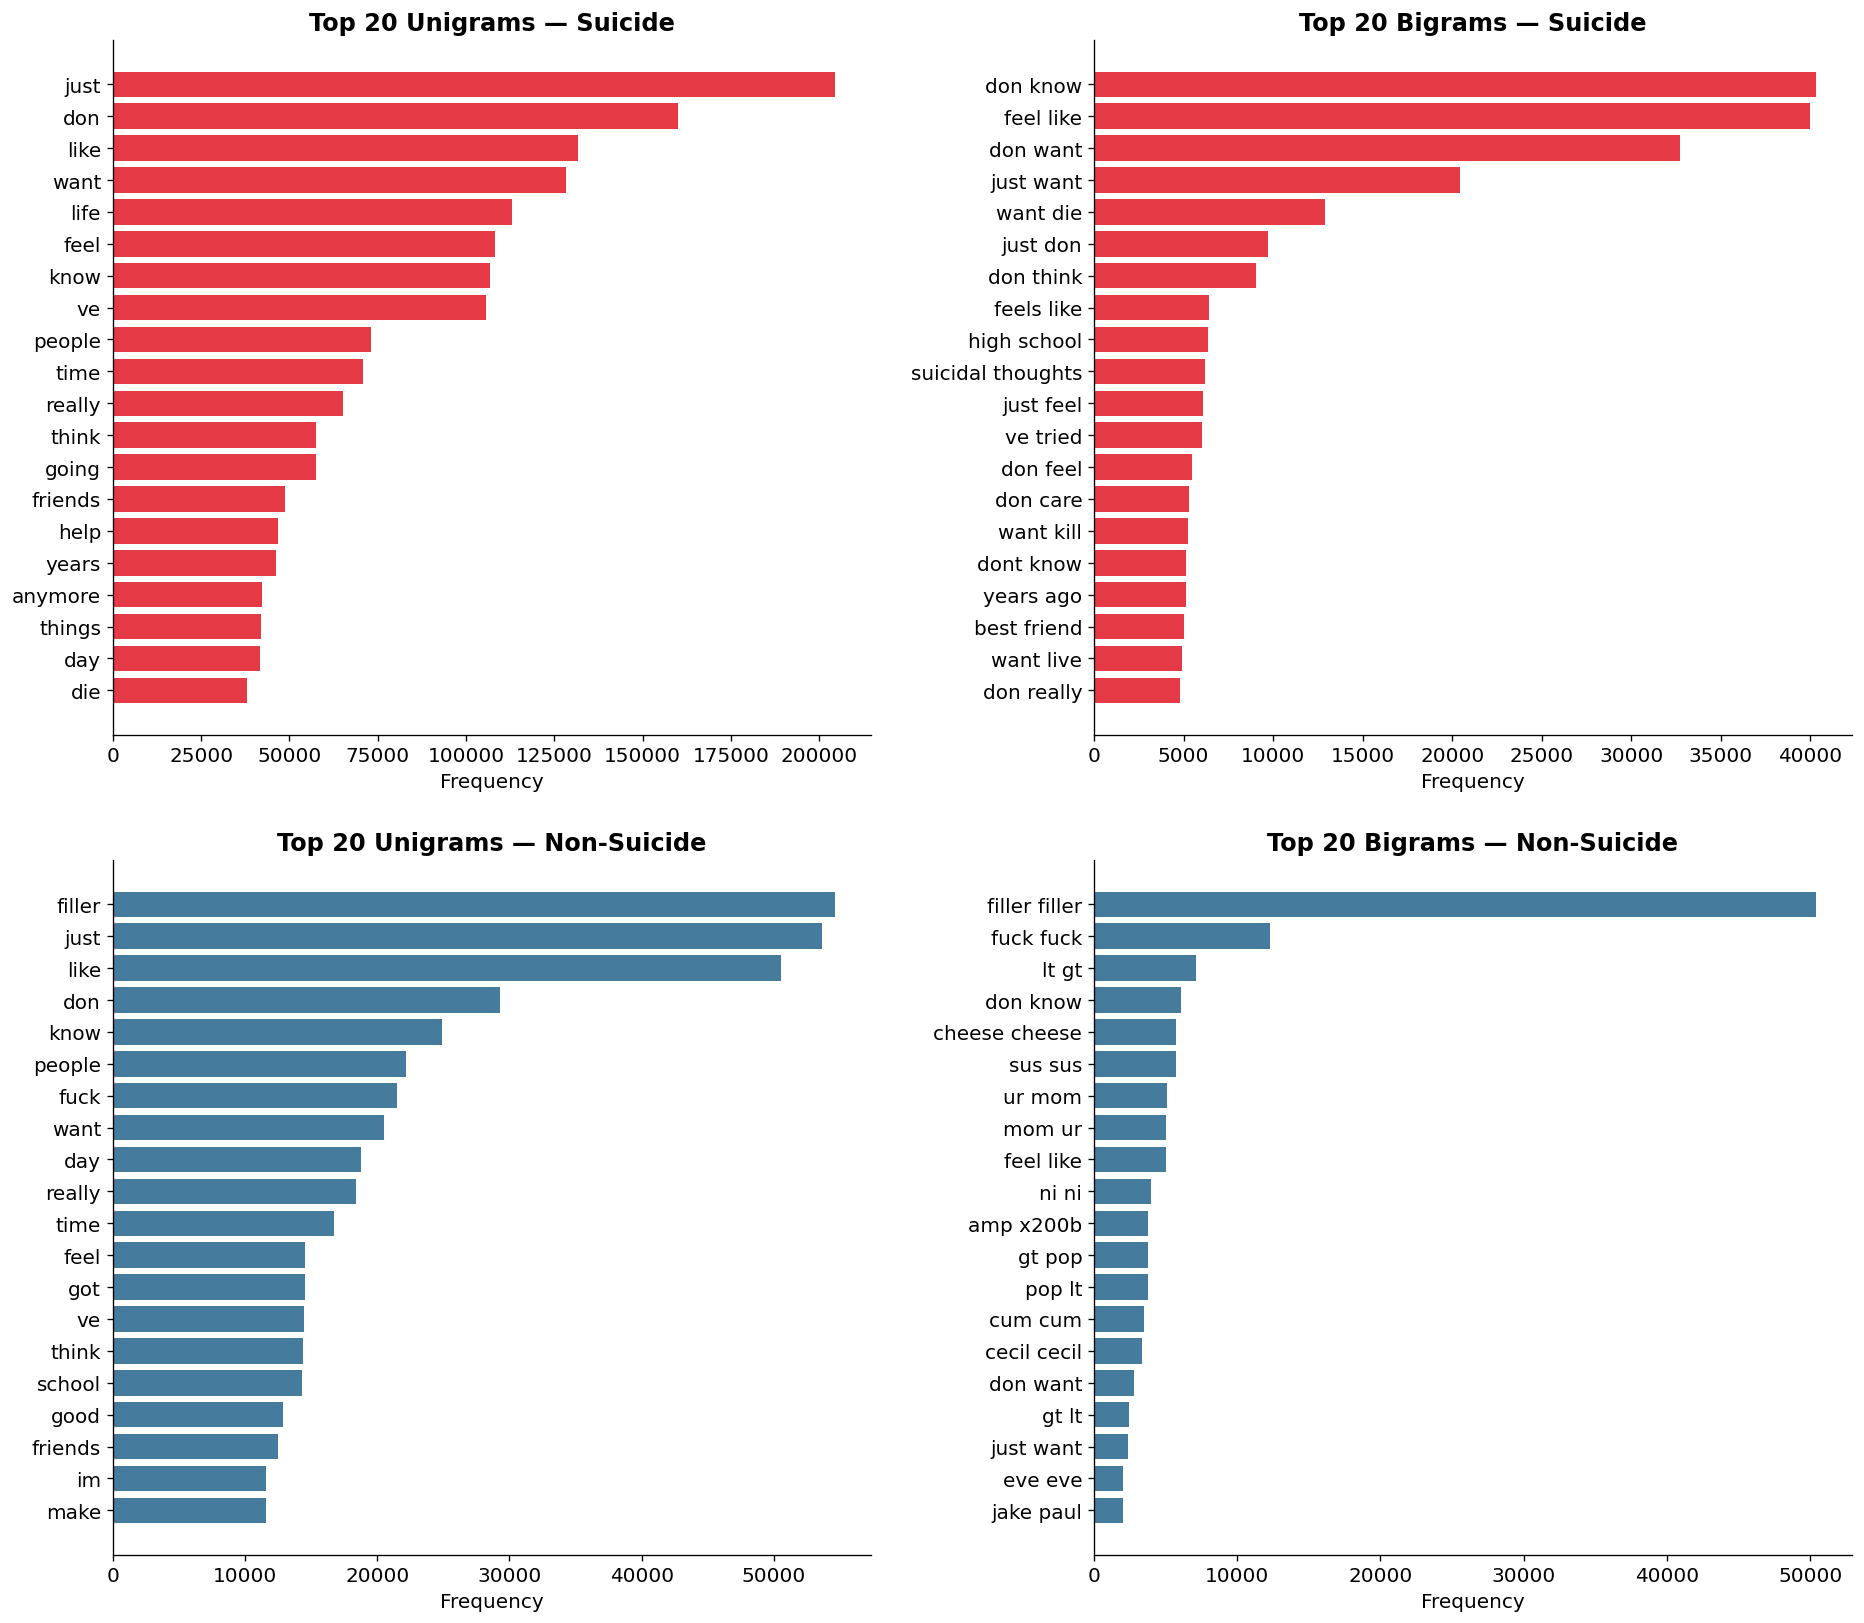

In [10]:
# Function to plot top n-grams
def plot_top_ngrams(corpus, n=1, top_k=20, ax=None, title='', color='steelblue'):
    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=50_000
    ).fit(corpus)

    bag = vec.transform(corpus)
    counts = bag.sum(axis=0).A1

    # Select top-k n-grams
    top_idx = counts.argsort()[-top_k:][::-1]
    terms = [vec.get_feature_names_out()[i] for i in top_idx]
    vals = [counts[i] for i in top_idx]

    # Plot horizontal bar chart
    ax.barh(terms[::-1], vals[::-1], color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Frequency')


# Create subplots for unigrams and bigrams across classes
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for row, label in enumerate(['suicide', 'non-suicide']):
    corpus = df[df['label'] == label]['text'].apply(simple_clean)
    color = PALETTE[label]

    for col, n, ng_label in [(0, 1, 'Unigrams'), (1, 2, 'Bigrams')]:
        plot_top_ngrams(
            corpus,
            n=n,
            top_k=TOP_N_NGRAMS,
            ax=axes[row][col],
            title=f'Top {TOP_N_NGRAMS} {ng_label} — {label.title()}',
            color=color
        )

# Adjust layout and save figure
plt.tight_layout(pad=2.0)
plt.savefig(PLOTS_DIR / 'eda' / 'top_ngrams.png', bbox_inches='tight')
plt.show()

## Linguistic Signal Feature Extraction

This section extracts linguistic signal features based on predefined lists of negation cues and intensifiers. These signals capture subtle language patterns that may reflect emotional intensity or negation in text.

For each post, the frequency of negation and intensifier terms is computed and then normalised by the total word count to obtain comparable ratios. Aggregating these features by class helps analyse whether such linguistic patterns differ systematically across categories.

In [11]:
# Count occurrences of signal words in text
def count_signal_words(text, signal_list):
    tokens = str(text).lower().split()
    return sum(t in signal_list for t in tokens)

# Compute signal counts
df['negation_count'] = df['text'].apply(lambda x: count_signal_words(x, NEGATION_CUES))
df['intensifier_count'] = df['text'].apply(lambda x: count_signal_words(x, INTENSIFIERS))

# Normalise by word count to obtain ratios
df['neg_ratio'] = df['negation_count'] / df['word_count'].clip(lower=1)
df['intens_ratio'] = df['intensifier_count'] / df['word_count'].clip(lower=1)

# Aggregate mean ratios by class
signal_summary = df.groupby('label')[['neg_ratio', 'intens_ratio']].mean().round(4)

print('Mean signal ratios by class:')
print(signal_summary)

Mean signal ratios by class:
             neg_ratio  intens_ratio
label                               
non-suicide     0.0133        0.0129
suicide         0.0258        0.0142


## Linguistic Signal Distribution Analysis

This section visualises the distribution of linguistic signal features, specifically negation and intensifier ratios, across different classes. Kernel density estimation (KDE) is used to compare how these features are distributed within each category.

To improve interpretability and reduce the influence of extreme values, the feature values are clipped at the 99th percentile before plotting. This allows for a clearer comparison of typical patterns and highlights potential differences in language usage between classes.

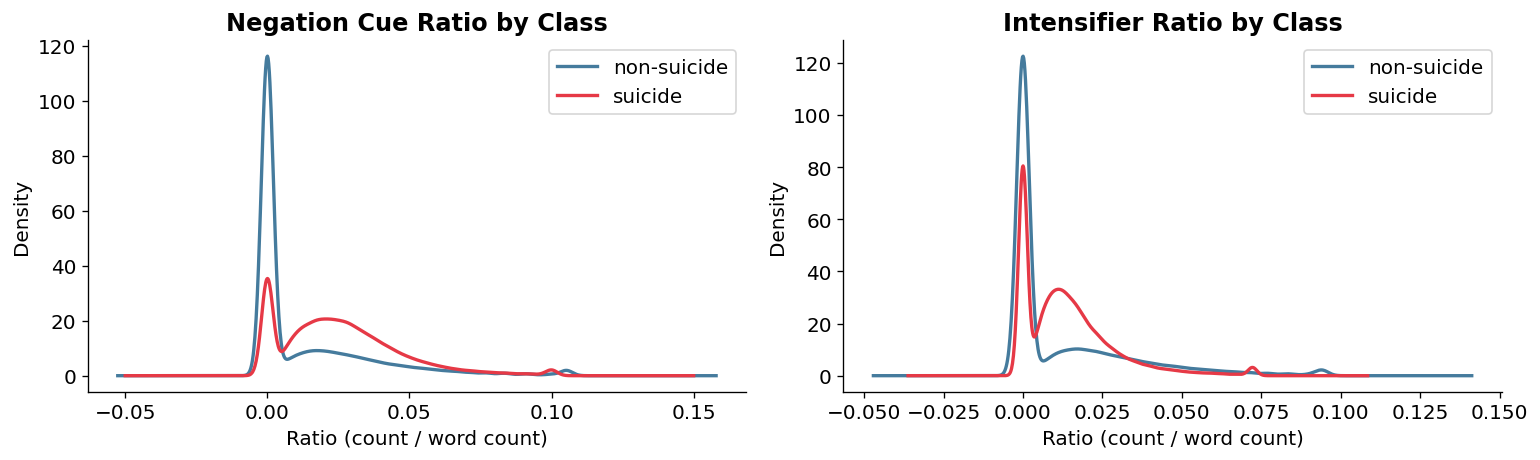

In [12]:
# Create subplots for linguistic signal distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Plot KDE distributions for each signal feature
for ax, col, title in zip(
    axes,
    ['neg_ratio', 'intens_ratio'],
    ['Negation Cue Ratio by Class', 'Intensifier Ratio by Class']
):
    for label, grp in df.groupby('label'):
        grp[col].clip(upper=grp[col].quantile(0.99)).plot.kde(
            ax=ax,
            label=label,
            color=PALETTE[label],
            linewidth=2
        )

    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Ratio (count / word count)')
    ax.legend()

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'linguistic_signal_distributions.png', bbox_inches='tight')
plt.show()

## Feature Correlation Analysis

This section examines the relationships between engineered numerical features and the target variable using a correlation matrix. The target labels are first converted into a binary format to enable numerical correlation analysis.

The heatmap provides a visual representation of pairwise correlations, helping identify strongly related features, potential redundancy, and features that may be predictive of the target. The upper triangle of the matrix is masked to improve readability and avoid duplicate information.

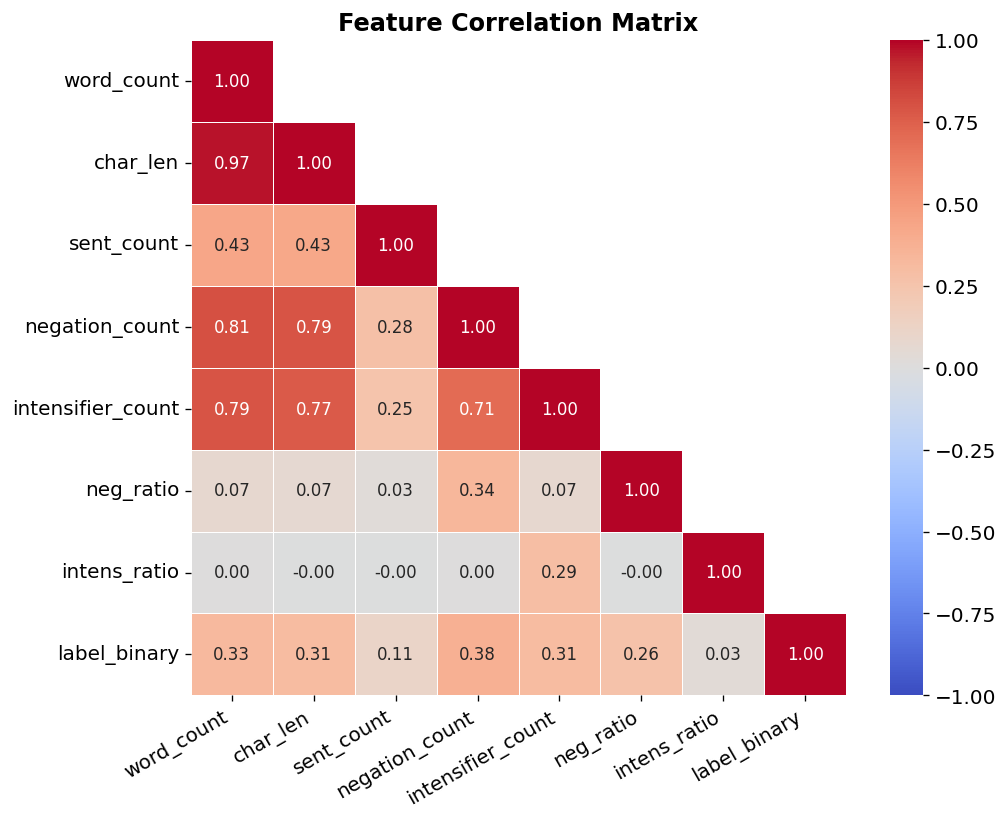

In [13]:
# Map labels to binary values for correlation analysis
df['label_binary'] = df['label'].map({'suicide': 1, 'non-suicide': 0})

# Select numerical features
num_cols = [
    'word_count', 'char_len', 'sent_count',
    'negation_count', 'intensifier_count',
    'neg_ratio', 'intens_ratio', 'label_binary'
]

# Compute correlation matrix
corr = df[num_cols].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# Plot heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 10}
)

# Rotate x-axis labels to 30 degrees for better readability
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

# Set Heatmap Title
ax.set_title('Feature Correlation Matrix', fontweight='bold')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'eda' / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()